# Cutout Size Histogram Workflow

This notebook walks through the full process of measuring the sizes of FITS cutouts and plotting their distributions inline.

Update `INPUT_DIR` in the next cell to point at the `split_images` directory you want to analyze.

In [1]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from astropy.io import fits

INPUT_DIR = Path("/Users/diegomiura/research/Hyrax-Research/data/split_images")
PATTERN = "*.fits"
BINS = 30
MAX_FILES = None

## Step 1: Find the cutout files

This gathers the FITS files that will be inspected.

If your cutouts live on a mounted or network-backed filesystem, avoiding per-file `is_file()` checks keeps this step much faster.

In [2]:
if not INPUT_DIR.exists():
    raise FileNotFoundError(f"Input directory does not exist: {INPUT_DIR}")

files = sorted(INPUT_DIR.glob(PATTERN), key=lambda path: path.name)
if not files:
    raise FileNotFoundError(f"No files matched {PATTERN!r} in {INPUT_DIR}")

if MAX_FILES is not None:
    files = files[:MAX_FILES]

print(f"Found {len(files)} FITS files in {INPUT_DIR}")
print("First few files:")
for path in files[:5]:
    print(f"  {path.name}")

Found 250 FITS files in /Users/diegomiura/research/Hyrax-Research/data/split_images
First few files:
  72_0_G_v2_hsc_realistic.fits
  72_0_I_v2_hsc_realistic.fits
  72_0_R_v2_hsc_realistic.fits
  72_0_Y_v2_hsc_realistic.fits
  72_0_Z_v2_hsc_realistic.fits


## Step 2: Read the image sizes from the FITS headers

For each file, the code reads `NAXIS1` and `NAXIS2`, which store the image width and height in pixels.

In [3]:
measurements = []
skipped_files = []

for path in files:
    try:
        with fits.open(path, memmap=True) as hdul:
            header = hdul[0].header
            naxis = int(header.get("NAXIS", 0))
            if naxis < 2:
                skipped_files.append((path.name, f"NAXIS={naxis}"))
                continue

            width = int(header["NAXIS1"])
            height = int(header["NAXIS2"])
            measurements.append(
                {
                    "filename": path.name,
                    "width": width,
                    "height": height,
                    "pixel_area": width * height,
                }
            )
    except Exception as exc:
        skipped_files.append((path.name, str(exc)))

print(f"Measured {len(measurements)} cutouts")
print(f"Skipped {len(skipped_files)} file(s)")

Measured 250 cutouts
Skipped 0 file(s)


## Step 3: Summarize the size distribution

This computes the width, height, and pixel area distributions, plus the exact count of each `(width, height)` pair.

In [4]:
if not measurements:
    raise RuntimeError("No readable 2D FITS cutouts were found.")

width_values = [row["width"] for row in measurements]
height_values = [row["height"] for row in measurements]
area_values = [row["pixel_area"] for row in measurements]
size_counts = Counter((row["width"], row["height"]) for row in measurements)

print(f"Width range: {min(width_values)} to {max(width_values)} pixels")
print(f"Height range: {min(height_values)} to {max(height_values)} pixels")
print(f"Unique size pairs: {len(size_counts)}")
print()
print("Most common sizes:")
for (width, height), count in size_counts.most_common(10):
    print(f"  {width}x{height}: {count}")

Width range: 53 to 537 pixels
Height range: 53 to 537 pixels
Unique size pairs: 23

Most common sizes:
  53x53: 130
  58x58: 10
  83x83: 10
  537x537: 5
  116x116: 5
  145x145: 5
  172x172: 5
  200x200: 5
  411x411: 5
  65x65: 5


In [5]:
summary_rows = [
    {
        "width": width,
        "height": height,
        "pixel_area": width * height,
        "count": count,
    }
    for (width, height), count in sorted(size_counts.items())
]

summary_rows

[{'width': 53, 'height': 53, 'pixel_area': 2809, 'count': 130},
 {'width': 55, 'height': 55, 'pixel_area': 3025, 'count': 5},
 {'width': 56, 'height': 56, 'pixel_area': 3136, 'count': 5},
 {'width': 57, 'height': 57, 'pixel_area': 3249, 'count': 5},
 {'width': 58, 'height': 58, 'pixel_area': 3364, 'count': 10},
 {'width': 62, 'height': 62, 'pixel_area': 3844, 'count': 5},
 {'width': 65, 'height': 65, 'pixel_area': 4225, 'count': 5},
 {'width': 69, 'height': 69, 'pixel_area': 4761, 'count': 5},
 {'width': 74, 'height': 74, 'pixel_area': 5476, 'count': 5},
 {'width': 80, 'height': 80, 'pixel_area': 6400, 'count': 5},
 {'width': 83, 'height': 83, 'pixel_area': 6889, 'count': 10},
 {'width': 85, 'height': 85, 'pixel_area': 7225, 'count': 5},
 {'width': 87, 'height': 87, 'pixel_area': 7569, 'count': 5},
 {'width': 88, 'height': 88, 'pixel_area': 7744, 'count': 5},
 {'width': 116, 'height': 116, 'pixel_area': 13456, 'count': 5},
 {'width': 127, 'height': 127, 'pixel_area': 16129, 'count': 5}

## Step 4: Plot the histograms inline

These plots stay in the notebook, so you can inspect the distributions without saving a separate image file.

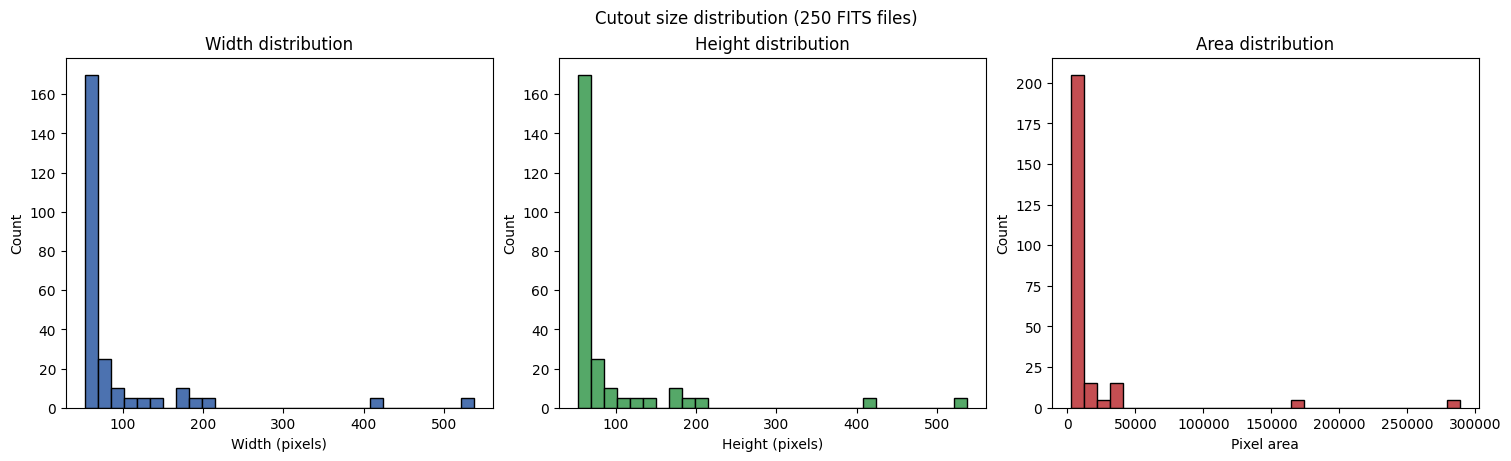

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

plot_specs = [
    ("Width distribution", "Width (pixels)", width_values, "#4C72B0"),
    ("Height distribution", "Height (pixels)", height_values, "#55A868"),
    ("Area distribution", "Pixel area", area_values, "#C44E52"),
]

for ax, (title, xlabel, values, color) in zip(axes, plot_specs):
    ax.hist(values, bins=min(BINS, len(values)), color=color, edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")

fig.suptitle(f"Cutout size distribution ({len(measurements)} FITS files)")
plt.show()

## Step 5: Plot exact size counts

If your cutouts come in a small number of discrete sizes, this bar chart is often easier to read than the histogram.

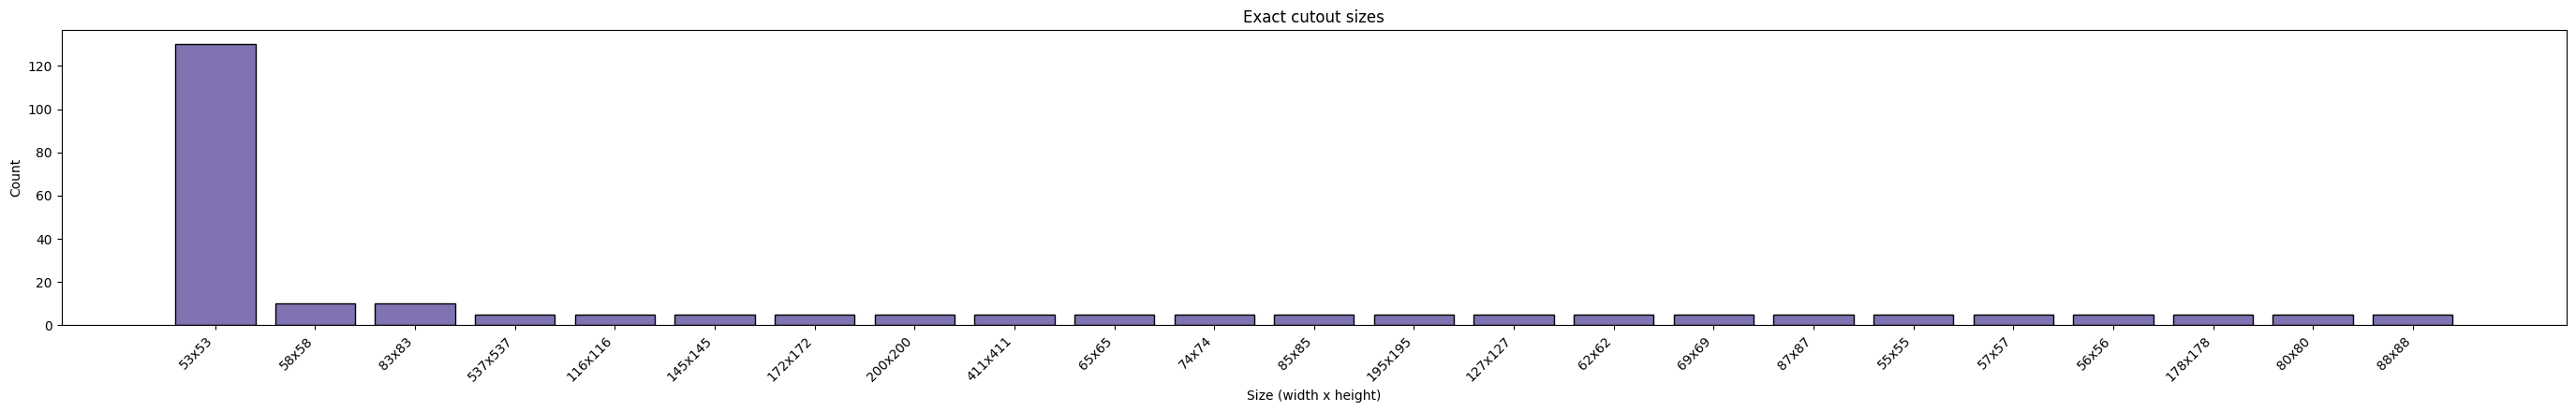

In [7]:
labels = [f"{width}x{height}" for (width, height), _count in size_counts.most_common()]
counts = [count for (_size, count) in size_counts.most_common()]

plt.figure(figsize=(max(8, len(labels) * 1.2), 4.5))
plt.bar(labels, counts, color="#8172B2", edgecolor="black")
plt.title("Exact cutout sizes")
plt.xlabel("Size (width x height)")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()